# Approach
1. Join all the data together
2. Handling missing-ness
3. Feature Creation
4. Feature Reduction
5. Train_Test_Split
6. Encoding data
7. Training the models (kNN, SGDRegressor)
8. Model selection
9. Model Evaluation
10. Determining Business Impact
11. Conclusion and recommendations

In [1]:
import jupyternotify
ip = get_ipython()
ip.register_magics(jupyternotify.JupyterNotifyMagics)

<IPython.core.display.Javascript object>

## Packages used

In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
# Report settings
pd.set_option('display.max_columns', None)
hs = 2 # dataframe head size - controls the number of rows to print; defaulted at 2 for compactness

# Joining all the data together

We start with importing all the files into DataFrames

In [4]:
list_filenames = ['Train_Demographics', 'Train_Claim', 'Train_Policy', 'Train_Vehicle', 'Traindata_with_Target']
list_df = []

for count, filename in enumerate(list_filenames):
    list_df.append(pd.read_csv(f'Datasets\\{filename}.csv'))
    list_df[count].name = filename

print(f'Checking file dimensions to ensure all are the same:')
for df in list_df:
    print(f'{df.name}: {df.shape}')

Checking file dimensions to ensure all are the same:
Train_Demographics: (28836, 10)
Train_Claim: (28836, 19)
Train_Policy: (28836, 10)
Train_Vehicle: (115344, 3)
Traindata_with_Target: (28836, 2)


"Train_Vehicle" has too many rows - this is because the data has been "pre-melted" and so we must pivot the data to give us the right dimension

In [5]:
# Checking to see how we should pivot the data
list_index = list_filenames.index('Train_Vehicle')
df = list_df[list_index]
df.head(hs)

,CustomerID,VehicleAttribute,VehicleAttributeDetails
0,Cust20179,VehicleID,Vehicle8898
1,Cust21384,VehicleModel,Malibu


In [6]:
# We need to pivot the data by 'VehicleAttribute' to retrieve its features
df = df.pivot(index='CustomerID',columns='VehicleAttribute', values='VehicleAttributeDetails')
print(df.shape)
list_df[list_index] = df
df.head(hs)

(28836, 4)


VehicleAttribute,VehicleID,VehicleMake,VehicleModel,VehicleYOM
CustomerID,,,,
Cust10000,Vehicle26917,Audi,A5,2008
Cust10001,Vehicle15893,Audi,A5,2006


Now that all datasets are of a similar structure, we can join the datasets.
We start by assigning "CustomerID" as the index for these dataframes - note that this means that we have made the decision that CustomerID is not correlated with ReportedFraud.

In [7]:
if len(list_df[1]['CustomerID'].value_counts()) == len(list_df[1]):
    print('CustomerID is unique for each row of the dataset - it can be used as the index')
else:
    print('Error - duplicated CustomerID detected')


CustomerID is unique for each row of the dataset - it can be used as the index


In [47]:
# Assigning 'CustomerID' as the index for all dataframes
for df in list_df:
    if df.index.name != 'CustomerID': df.set_index('CustomerID', inplace=True)

# Joining the dataframes to the first dataframe
df_joined = list_df[0].join(list_df[1:], how='left')
print(f'Combined dataset size: {df_joined.shape}')
df_joined.head(hs)

Combined dataset size: (28836, 41)


,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17,3,?,1,0,?,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N


print(df_joined.columns)

# Checking labels for potential class imbalance

Percentage of Customers with Reported Fraud: 27.0%


<AxesSubplot:xlabel='ReportedFraud'>

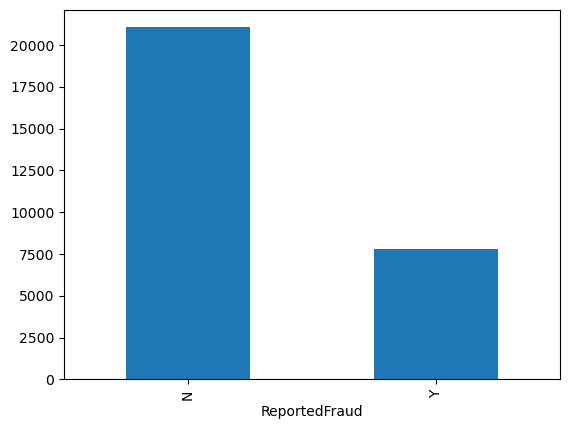

In [10]:
df_grouped = df_joined.groupby(['ReportedFraud'])['InsurancePolicyNumber'].count()

print(f'Percentage of Customers with Reported Fraud: {round((df_grouped["Y"]/df_grouped.sum())*100, 2)}%')

df_grouped.plot.bar()

As we can see, we do have some class imbalance here.
Instead of oversampling the minority class, however, we will deal with it by choosing techniques that are either less impacted by imbalance (e.g. MLPClassifier) or one that has the in-built ability in sklearn to correct this through weighting (e.g. LogisticRegression)

# Dealing with missing data
## Finding missing data
 - We know from the data descriptions that there are missing data
     - InsuredGender: NaN
     - ContractType: "NA" --> this field does not exist in dataset
     - TypeOfCollission: "?"
     - IncidentTime: -5
     - PropertyDamage: "?"
     - Witnesses: "MISSINGVALUE"
     - PoliceReport: "?"
     - AmountOfTotalClaim: "MISSEDDATA"
     - VehicleAttributeDetails: "???"
 - We could have determined the above by calling df.value_counts() for each column of the dataframe, but we have excluded it here for compactness of the report
 - While some of the missing data will be useful to capture as additional information, we will first cast all missing data to the np.NaN type

In [49]:
# We first get a feel for how many columns have an actual 'NaN' as missing values
df_missing = pd.Series(df_joined.isnull().sum())
print(df_missing[df_missing>0])

InsuredGender    30
Country           2
dtype: int64


In [50]:
# Replacing the only numerical "missing" data first
df_joined['IncidentTime'].replace(-5, np.NaN, inplace=True)

# Replacing all the missing values that are populated with strings
missing_values = ['MISSINGVALUE', 'MISSEDDATA', '?', '???']
df_joined.replace(missing_values, np.NaN, inplace=True)

df_missing = pd.Series(df_joined.isnull().sum())
print(df_missing[df_missing>0])

InsuredGender            30
Country                   2
TypeOfCollission       5162
IncidentTime             31
PropertyDamage        10459
Witnesses                46
PoliceReport           9805
AmountOfTotalClaim       50
VehicleMake              50
dtype: int64


## Dealing with missingness from a few small datapoints
The following features have missing data that consists of only a fraction of the total dataset: <br> InsuredGender, Country, IncidentTime, Witnesses, AmountOfTotalClaim, VehicleMake

As the change to dataset size is immaterial, we can confidently drop those datapoints without affecting the analysis.

In [51]:
# Storing in a new dataframe for ease of re-running the cell
df_dropped = df_joined.dropna(subset=['InsuredGender', 'Country', 'IncidentTime', 'Witnesses', 
                                     'AmountOfTotalClaim', 'VehicleMake'])

print(f'We have reduced the total number of rows by: {len(df_joined) - len(df_dropped)}')
print(f'This has resulted in a {round((1-len(df_dropped)/len(df_joined))*100, 2)}% reduction in dataset size')

We have reduced the total number of rows by: 128
This has resulted in a 0.44% reduction in dataset size


## Dealing with material missingness
Missingness from other attributes cannot be dealt with in the same way, as this would affect the dataset too much.
Instead of ignoring the attribute, we will treat the 'Missing' data as a type of category, as we don't know whether the presence (or not) of the data is correlated to the ReportedFraud field. We can test this assumption later.

In [52]:
# Checking again to see which fields are most affected
df_missing = df_dropped.isnull().sum()
df_missing = df_missing[df_missing>0]

df_missing = round(df_missing / len(df_dropped)*100, 2)

print(f'% of total dataset missing these fields:')
print(df_missing)

% of total dataset missing these fields:
TypeOfCollission    17.90
PropertyDamage      36.27
PoliceReport        34.02
dtype: float64


The above fields are missing too data to be relied upon for future datapoints, and are also categorical in nature, which means there is no reliable way (besides some form of clustering algorithm) to impute these datapoints, so we will drop them.

# Feature Creation and Extraction
Examining some of the features, we can see that there is an opportunity to create new features that are more relevant for the analysis, namely:

- **CapitalProfit**: it may be easier for the model to correlate the net loss or gain of capital by combining the two columns
- **DayOfIncident**: as these are all historical dates, and the purpose of the model to classify existing and new customers, the actual "DateOfIncident" is less useful; however, the day of the week of the incident could be used
- **TimeToIncident**: similar to the above, we can extract how long it took how for an 'incident' to occur after the date the policy began
- **Policy_LowerSingleLimit** & **Policy_UpperSingleLimit**: 'Policy_CombinedSingleLimit' is a string value that appears to denote two separate values, which we can separate here

In [53]:
# Creating a new dataframe to help with re-running the cell
df = df_dropped.copy(deep=True)
df['CapitalProfit'] = df['CapitalGains'] + df['CapitalLoss']
#df['DayOfIncident'] = pd.to_datetime(df['DateOfIncident']).dt.day_of_week
#df['TimeToIncident'] = (pd.to_datetime(df['DateOfIncident'])-pd.to_datetime(df['DateOfPolicyCoverage'])).dt.days
df[['Policy_LowerSingleLimit', 'Policy_UpperSingleLimit']] = df['Policy_CombinedSingleLimit'].str.split('/', expand=True)
df.head(hs)

,InsuredAge,InsuredZipCode,InsuredGender,InsuredEducationLevel,InsuredOccupation,InsuredHobbies,CapitalGains,CapitalLoss,Country,DateOfIncident,TypeOfIncident,TypeOfCollission,SeverityOfIncident,AuthoritiesContacted,IncidentState,IncidentCity,IncidentAddress,IncidentTime,NumberOfVehicles,PropertyDamage,BodilyInjuries,Witnesses,PoliceReport,AmountOfTotalClaim,AmountOfInjuryClaim,AmountOfPropertyClaim,AmountOfVehicleDamage,InsurancePolicyNumber,CustomerLoyaltyPeriod,DateOfPolicyCoverage,InsurancePolicyState,Policy_CombinedSingleLimit,Policy_Deductible,PolicyAnnualPremium,UmbrellaLimit,InsuredRelationship,VehicleID,VehicleMake,VehicleModel,VehicleYOM,ReportedFraud,CapitalProfit,Policy_LowerSingleLimit,Policy_UpperSingleLimit
CustomerID,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
Cust10000,35,454776,MALE,JD,armed-forces,movies,56700,-48500,India,2015-02-03,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City1,Location 1311,17.0,3,NaN,1,0,NaN,65501,13417,6071,46013,119121,49,1998-10-25,State1,100/300,1000,1632.73,0,not-in-family,Vehicle26917,Audi,A5,2008,N,8200,100,300
Cust10001,36,454776,MALE,JD,tech-support,cross-fit,70600,-48500,India,2015-02-02,Multi-vehicle Collision,Side Collision,Total Loss,Police,State7,City5,Location 1311,10.0,3,YES,2,1,YES,61382,15560,5919,39903,119122,114,2000-11-15,State1,100/300,1000,1255.19,0,not-in-family,Vehicle15893,Audi,A5,2006,N,22100,100,300


# Dimensionality Reduction
Now that we have additional features extracted, we can begin the process of removing certain features that may be obviously redundant or similar:
 - **Country**: Examining the data, it suggests that we only have data belonging to 'India', so our model must either by relevant only to India, or it must classify independently of country; therefore, we can drop this
 - **DateOfIncident**: The exact historical date won't help us with future datapoints, and we have already extracted a feature from this
 - **IncidentState** and **IncidentAddress**: It is unlikely that we need the Address itself, and having the **IncidentCity** will already inform the **IncidentState**; therefore these two are redundant / synonymous
 - **AmountOfInjuryClaim, AmountOfPropertyClaim, AmountOfVehicleDamage**: These are all the component parts of **AmountOfTotalClaim**, so we remove these
 - **InsurancePolicyNumber**: We can see that this is a unique identifier per customer, just like **CustomerID**, therefore we can drop this as we are already using **CustomerID** as the index
 - **Policy_CombinedSingleLimit**: We have split this out into two features, so we can remove this redundant column
 - **VehicleID**: The unique identifier for each vehicle covered is unlikely to be correlated with Fraud, so we can drop this

In [54]:
# Testing country
print(df['Country'].value_counts())

# Testing InsurancePolicyNumber
print(f'One InsurancePolicyNumber for each CustomerID? {len(df)==len(df["InsurancePolicyNumber"].unique())}')

# Testing VehicleID
print(f'One VehicleID for each CustomerID? {len(df)==len(df["VehicleID"].unique())}')

India    28708
Name: Country, dtype: int64
One InsurancePolicyNumber for each CustomerID? True
One VehicleID for each CustomerID? True


In [17]:
# Dropping columns
# Storing the result back into df_dropped to help with re-running this cell

df_dropped = df.drop(columns=['Country', 'DateOfIncident', 'IncidentState', 'IncidentAddress', 'AmountOfInjuryClaim'
                     , 'AmountOfPropertyClaim', 'AmountOfVehicleDamage', 'InsurancePolicyNumber'
                     , 'Policy_CombinedSingleLimit', 'VehicleID', 'DateOfPolicyCoverage'])#, 'TypeOfCollission'
                     #, 'PropertyDamage', 'PoliceReport'])

print(f'{df.shape[1] - df_dropped.shape[1]} columns dropped; new shape is: {df_dropped.shape}')

11 columns dropped; new shape is: (28708, 33)


# Feature Engineering - Encoding and Scaling the training data
Before we use a data mining technique on the data, we must first encode the categorical data into nominal values so that the techniques can digest the data; additionally, we should rescale the continuous data to avoid over-weighting one category over another due purely to their inherent scales (e.g. AmountOfTotalClaim in dollars vs Witnesses as integers)

**Encoding categorical data**
We will need to use two approaches here:
1. Turn binary features into 1s and 0s using OrdinalEncoder
2. Use One-of-K encoding for non-binary features
    - For features with high cardinality, we need to reduce the cardinality first

To avoid data leakage, we will not do this directly on the dataset now, but apply these transformations during cross-validation; however, we do need to understand which columns should have which types of data.

In [55]:
# Replacing missing values with a label
df_dropped = df_dropped.replace(np.NaN, 'MISSING_DATA')

# Determining the number of unique values in each feature in the training set
print('Number of unique values for each feature')
col_dict = {}
for col in df_dropped.columns:
    col_dict[col] = len(df_dropped[col].unique())

unique_vals = pd.Series(col_dict).sort_values()
unique_vals

Number of unique values for each feature


Country                           1
ReportedFraud                     2
InsuredGender                     2
InsurancePolicyState              3
PoliceReport                      3
PropertyDamage                    3
BodilyInjuries                    3
TypeOfIncident                    4
TypeOfCollission                  4
SeverityOfIncident                4
NumberOfVehicles                  4
Witnesses                         4
AuthoritiesContacted              5
InsuredRelationship               6
IncidentState                     7
IncidentCity                      7
InsuredEducationLevel             7
Policy_CombinedSingleLimit        9
VehicleMake                      14
InsuredOccupation                14
InsuredHobbies                   20
VehicleYOM                       21
IncidentTime                     24
VehicleModel                     39
InsuredAge                       46
DateOfIncident                   72
CapitalGains                    338
CapitalLoss                 

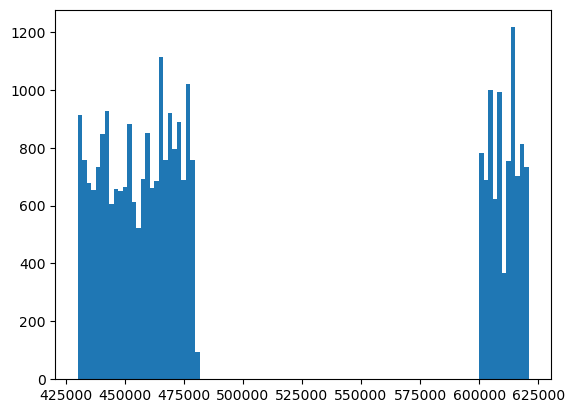

In [19]:
plt.hist(df_dropped['InsuredZipCode'], bins=100)
plt.show()

In [20]:
df_dropped['InsuredZipCode'] = df_dropped['InsuredZipCode'].astype(str).apply(lambda x: x[:2]).astype(str)

In [56]:
# The target column to use LabelBinarizer on
target_column = ['ReportedFraud']

# The columns to use OrdinalEncoder on
ordinal_columns = ['InsuredGender']

# The columns to use StandardScaler on
scaled_columns = ['InsuredAge', 'CapitalGains', 'CapitalLoss', 'NumberOfVehicles', 'BodilyInjuries'
                 , 'Witnesses', 'AmountOfTotalClaim', 'CustomerLoyaltyPeriod', 'Policy_Deductible', 'PolicyAnnualPremium'
                 , 'UmbrellaLimit', 'VehicleYOM', 'CapitalProfit', 'Policy_LowerSingleLimit'
                 , 'Policy_UpperSingleLimit', 'IncidentTime']

columns_to_drop = []

# The columns to use OneHotEncoder on
onehot_columns = list(set(df_dropped.columns) - set(ordinal_columns) - set(target_column) - set(scaled_columns) - set(columns_to_drop))
print(onehot_columns)

['TypeOfCollission', 'InsuredOccupation', 'IncidentState', 'AuthoritiesContacted', 'IncidentCity', 'AmountOfVehicleDamage', 'VehicleModel', 'InsuredEducationLevel', 'Policy_CombinedSingleLimit', 'SeverityOfIncident', 'AmountOfInjuryClaim', 'InsuredHobbies', 'IncidentAddress', 'VehicleID', 'Country', 'InsuredZipCode', 'PoliceReport', 'DateOfPolicyCoverage', 'VehicleMake', 'InsurancePolicyState', 'InsuredRelationship', 'TypeOfIncident', 'InsurancePolicyNumber', 'AmountOfPropertyClaim', 'PropertyDamage', 'DateOfIncident']


In [22]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler, LabelBinarizer, label_binarize

# This is used so we don't attempt the same transformation on all the features
from sklearn.compose import make_column_transformer, ColumnTransformer

In [23]:
def separate_xy(df):
    df_y = label_binarize(df[target_column], classes=['N', 'Y']).ravel()
    df_X = df.replace(np.NaN, 'MISSING_DATA').drop(columns=target_column)
    
    #print(df[target_column][:5])
    #print(df_y[:5])
    
    return df_X, df_y

In [24]:
prep_transformer = ColumnTransformer(transformers=[('standardscaler', StandardScaler(), scaled_columns)
                                                     ,('ordinalencoder', OrdinalEncoder(), ordinal_columns)
                                                     ,('onehotencoder', OneHotEncoder(), onehot_columns)]
                                                     ,remainder='drop')


# Preparing the training and test set parameters for the techniques
Note: due to the layout of the assignment, we will first use the sklearn provided tools of GridSearchCV, then we will use cross_validation in the final section where we compare the models

In [25]:
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import precision_recall_fscore_support, balanced_accuracy_score, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, f1_score
from sklearn.pipeline import make_pipeline, Pipeline

In [26]:
# Helper function to show performance metrics
def show_performance_metrics(y_test, y_pred, clf, normalize='pred'):
    print(f'Balanced Accuracy is: {balanced_accuracy_score(y_test, y_pred)}')
    print(f'Precision and Recall are: {precision_recall_fscore_support(y_test, y_pred, average="weighted")[:2]}')
    print(f'Weighted F1_Score is: {f1_score(y_test, y_pred, pos_label=1, average="weighted")}')
    
    cm = confusion_matrix(y_test, y_pred, normalize=normalize)
    conf_matrix = ConfusionMatrixDisplay(confusion_matrix=cm)
    conf_matrix.plot()
    plt.show()

In [27]:
X,y = separate_xy(df_dropped)

# Setting random_state=42 so that comments in report are consistent
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.33, shuffle=True, stratify=y, random_state=42)
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(19234, 32) (19234,)
(9474, 32) (9474,)


# Technique 1: LogisticRegression
This technique has been chosen for its speed of calculation as well as its ability to deal with class imbalance easily through the sklearn implementation


## Initial hyper-parameter selection and model training

In [28]:
from sklearn.linear_model import LogisticRegression

Balanced Accuracy is: 0.8008254193853552
Precision and Recall are: (0.8321746108759203, 0.8160227992400253)
Weighted F1_Score is: 0.8211801148875543


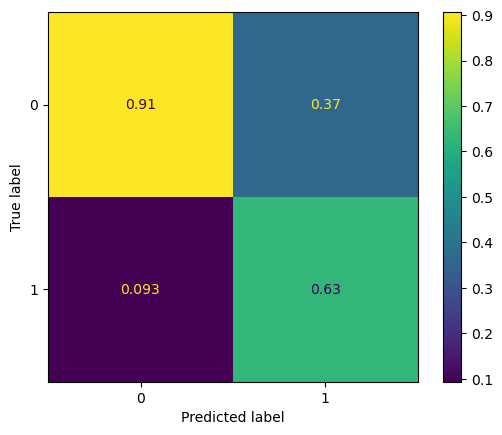

In [29]:
# Using RFE to trim down the number of features

init_lgr = LogisticRegression(class_weight='balanced', max_iter=100, solver='liblinear')

lgr_clf = make_pipeline(prep_transformer, init_lgr)
lgr_model = lgr_clf.fit(X_train, y_train)
y_pred = lgr_model.predict(X_test)

show_performance_metrics(y_test, y_pred, init_lgr)

## Tuning hyper-parameters using GridSearch and Cross Validation (inner only)
 - We will use GridSearchCV to optimise for this training set
 - Cross Validation is part of this process, but to preserve the assessment structure, we will implement Nested CV later and only use one 'layer' of CV here

In [30]:
logreg = LogisticRegression(class_weight='balanced', n_jobs=-1)
logreg_pipe = Pipeline([('preprocessing', prep_transformer), ('logisticregression', logreg)])

lgr_params = {'logisticregression__max_iter' : [100,200,300]
         ,'logisticregression__penalty' : ['l1','l2']
         ,'logisticregression__solver' : ['lbfgs', 'liblinear', 'newton-cg']}


In [31]:
%%timeit -n1 -r1
%%capture --no-display

logreg_clf = GridSearchCV(logreg_pipe, param_grid = lgr_params, error_score=0)
logreg_model = logreg_clf.fit(X_train, y_train)
y_pred = logreg_model.predict(X_test)

1min 19s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


Balanced Accuracy is: 0.8001667276388481
Precision and Recall are: (0.831701004038244, 0.815600591091408)
Weighted F1_Score is: 0.8207548649405256


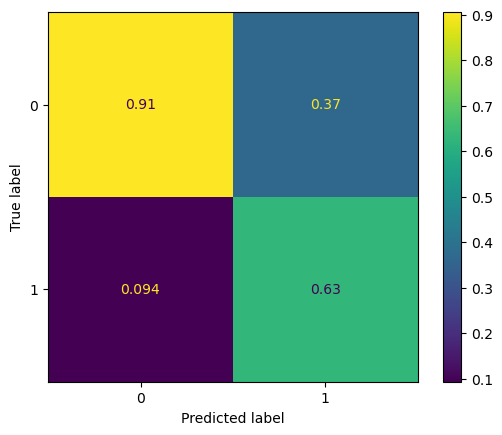

{'logisticregression__max_iter': 100, 'logisticregression__penalty': 'l1', 'logisticregression__solver': 'liblinear'}


In [32]:
show_performance_metrics(y_test, y_pred, logreg_clf)
print(logreg_clf.best_params_)

With this particular test set, we can say that:
 - Our balanced error rate is ~20%
 - Our Precision / Predict score is ~83%

Unfortunately the GridSearch did not yield further benefits

# Technique 2: Neural Network
A more flexible model is used here - the Multi-Layer Perceptron, which not only does not rely on a fixed basis function, but can also be more resilient to class imbalance.

In [33]:
from sklearn.neural_network import MLPClassifier

## Initial hyper-parameter assumptions

In [34]:
mlp_clf = make_pipeline(prep_transformer,
                        MLPClassifier(hidden_layer_sizes = (100,), activation='logistic',
                                      solver='sgd', learning_rate='adaptive', max_iter=200))

Balanced Accuracy is: 0.7541070303713817
Precision and Recall are: (0.8247398188906216, 0.8314333966645556)
Weighted F1_Score is: 0.8249364114775487


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


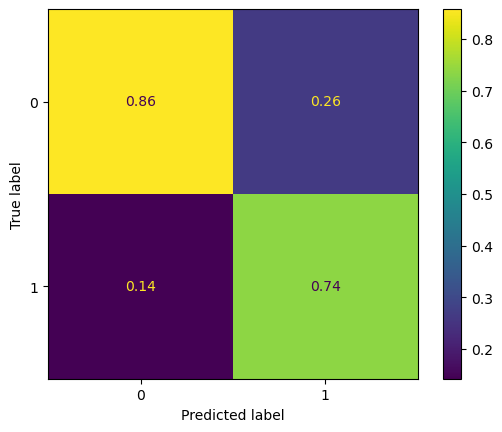

18.5 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


<IPython.core.display.Javascript object>

In [35]:
%%notify
%%timeit -n1 -r1

mlp_model = mlp_clf.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)

show_performance_metrics(y_test, y_pred, mlp_clf)

The initial fit, though it did not converge, was a better fit than the LogisticRegression.
We can try and get a stronger fit through hyper-parameter tuning

## Tuning hyper-parameters

In [36]:
mlp_pipe = Pipeline([('preprocessing', prep_transformer), ('mlp', MLPClassifier(max_iter=1000, early_stopping=True))])
mlp_params = {'mlp__hidden_layer_sizes' : [(100,100), (100,100,100), (200, 200)]
         ,'mlp__activation' : ['logistic', 'relu']
         ,'mlp__solver' : ['sgd', 'lbfgs', 'adam']
         ,'mlp__learning_rate' : ['adaptive', 'constant']}

In [57]:
%%notify
%%timeit -n1 -r1

#Limiting GridSearchCV to 3 folds to save on compute time
mlp_clf = GridSearchCV(mlp_pipe, mlp_params, error_score=0, cv=3, n_jobs=4)
mlp_model = mlp_clf.fit(X_train, y_train)
y_pred = mlp_model.predict(X_test)
show_performance_metrics(y_test, y_pred, mlp_clf)
print(mlp_clf.best_params_)

KeyboardInterrupt: 

<IPython.core.display.Javascript object>

GridSearch provides us with a clue that a loigstic activation function using the adam solver provides the best fit, along with 3 hidden layers - though extending this further may result in overfitting.

# Comparing the two models
To retrieve the generalised performance for these two models so that we can compare them, we will put the algorithms into a nested cross-validation process and then retrieve their AUC from the ROC curve.

In [38]:
scoring = {'bal_acc' : 'balanced_accuracy'
          ,'f1' : 'f1_weighted'
          ,'detect' : 'precision'
          ,'roc_auc' : 'roc_auc_ovo_weighted'}

In [39]:
from sklearn.model_selection import cross_val_score, StratifiedKFold, cross_validate
# Default n_splits=5 is used to balance finding variance/bias in the folds and compute time - particularly for MLP
inner_cv = StratifiedKFold(shuffle=True, random_state=42) 
outer_cv = StratifiedKFold(shuffle=True, random_state=42)

In [40]:
%%timeit -n1 -r1
%%notify
# Running nested cv for the LogisticRegression model
logreg_clf = GridSearchCV(logreg_pipe, param_grid=lgr_params, error_score=0, cv=inner_cv, n_jobs=4, refit=True)
logreg_nested_cv = cross_validate(logreg_clf, X=X_train, y=y_train, cv=outer_cv, n_jobs=4, scoring=scoring)

<IPython.core.display.Javascript object>

59.4 s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [41]:
print(logreg_nested_cv)

{'fit_time': array([39.04520512, 42.37222981, 37.27219987, 41.44276905, 21.72135305]), 'score_time': array([0.05905223, 0.05605006, 0.0800724 , 0.05505157, 0.04904461]), 'test_bal_acc': array([0.79326755, 0.79504754, 0.80774938, 0.78690216, 0.79424291]), 'test_f1': array([0.81342749, 0.8157662 , 0.82363976, 0.80712236, 0.8179506 ]), 'test_detect': array([0.61604361, 0.62087912, 0.63109049, 0.60508083, 0.62811245]), 'test_roc_auc': array([0.84931417, 0.84923392, 0.86358822, 0.84414049, 0.85105795])}


In [42]:
%%timeit -n1 -r1
%%notify

# Running nested cv for the Neural Network model
mlp_clf = GridSearchCV(mlp_pipe, mlp_params, error_score=0, cv=inner_cv, n_jobs=4)
mlp_nested_cv = cross_validate(mlp_clf, X=X_train, y=y_train, cv=outer_cv, n_jobs=4, scoring=scoring)

<IPython.core.display.Javascript object>

36min 40s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [45]:
print(f'LogisticRegression Mean Detect score: {logreg_nested_cv["test_detect"].mean()}')
print(f'Neural Network Mean Detect score: {mlp_nested_cv["test_detect"].mean()}')

LogisticRegression Mean Detect score: 0.6202413006066475


KeyError: 'test_detect'

In [46]:
print(mlp_nested_cv)

{'fit_time': array([1527.88153028, 1647.58150506, 1699.88485169, 1651.00845289,
        671.65215421]), 'score_time': array([0.07907176, 0.09008193, 0.06205678, 0.07706976, 0.04103732]), 'test_score': array([0.90252145, 0.90096179, 0.90824019, 0.90304133, 0.90691628])}


From the above, we can see that the neural network has a more robust score of 91%, and we can choose to select this model rather than the LogisticRegression for the application.

## Model Comparison: ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, RocCurveDisplay

In [ ]:
%%timeit -n1 -r1
%%notify

best_logreg = logreg_clf.fit(X_train, y_train)
y_pred_lgr =  best_logreg.predict(X_test)

In [ ]:
%%timeit -n1 -r1
%%notify

best_mlp = mlp_clf.fit(X_train, y_train)
y_pred_mlp =  best_mlp.predict(X_test)

In [ ]:
lgr_fpr, lgr_tpr, lgr_thresholds = roc_curve(y_test, y_pred_lgr, pos_label=1)
lgr_auc = roc_auc_score(y_test, y_pred_lgr)


mlp_fpr, mlp_tpr, mlp_thresholds = roc_curve(y_test, y_pred_mlp, pos_label=1)
mlp_auc = roc_auc_score(y_test, y_pred_mlp)

In [ ]:
plt.plot(lgr_fpr, lgr_tpr, label=f'LogisticRegression, AUC={round(lgr_auc, 4)}')
plt.plot(mlp_fpr, mlp_tpr, label=f'MLPClassifier, AUC={round(mlp_auc, 4)}')
plt.legend()
plt.show()

Based on the ROC curves, we would select the Neural Network / MLP Classifier model as the recommended model to put into production, if the project were to progress.

In [ ]:
show_performance_metrics(y_test, y_pred_mlp, best_mlp, 'all')

In [ ]:
cm = confusion_matrix(y_test, y_pred_mlp, normalize='all')
tpr=cm[1,1]
tnr=cm[0,0]
fpr = cm[0,1]
fnr = cm[1,0]
print(f'TPR: {tpr}, TNR: {tnr}')
print(f'FPR: {fpr}, FNR: {fnr}')

# Calculating Business Metrics

In [ ]:
avg_claim_amount = round(df_joined['AmountOfTotalClaim'].astype(float).mean() , 2)
total_claim_amount = round(df_joined['AmountOfTotalClaim'].astype(float).sum(), 2)
print(f'Average claim amount: {avg_claim_amount:,}')
print(f'Total amount claimed: {total_claim_amount:,}')


total_customers = len(df_joined['AmountOfTotalClaim']) * 10
print(f'Estimated Total Customer Base Size: {total_customers:,}')

required_profit = round(2*total_claim_amount, 2)
print(f'Required Total Profit: {required_profit:,}')

avg_policy_revenue = round(3*total_claim_amount/total_customers, 2)
print(f'Required Average Policy Price: {avg_policy_revenue:,}')

print(f'The ratio of average fraud cost to average policy revenue is: {round(avg_claim_amount/avg_policy_revenue,2):,}')

missclassified_lost_customers = round(total_customers * fpr)
print(f'Number of customers falsely accused of fraud: {missclassified_lost_customers:,}')

missclassified_lost_revenue = round(missclassified_lost_customers * avg_policy_revenue, 2)
print(f'Revenue lost due to falsely accussed customers leaving: {missclassified_lost_revenue:,}')

found_fraudsters = round(total_customers * 0.1 * tpr)
print(f'Number of fraudsters found: {found_fraudsters:,}')

print(f'Ratio of missclassified genuine customers to fraudsters found is: {round(missclassified_lost_customers/found_fraudsters, 2):,}')

saved_fraud_costs = round(found_fraudsters * avg_claim_amount, 2)
print(f'Total false claim costs saved: {saved_fraud_costs:,}')

profit_impact = round(saved_fraud_costs - missclassified_lost_revenue, 2)
print(f'Total Profit Impact of implementing this classifier: {profit_impact:,}')